ds
1986-01-01    229
1986-02-01    225
1986-03-01    194
1986-04-01    142
1986-05-01    123
Freq: MS, Name: y, dtype: int64

1986-01-01 00:00:00 --- 2026-02-01 00:00:00 freq: MS


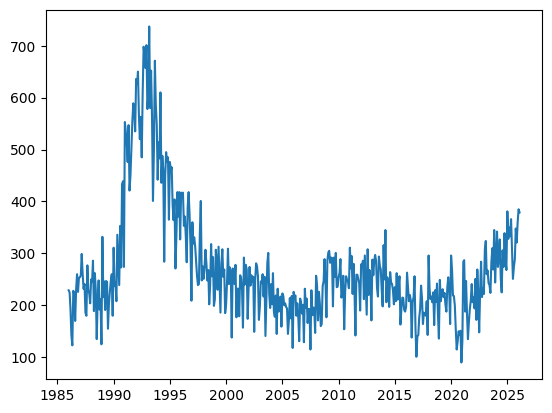

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np


path = "/Users/lauriwikberg/Desktop/pr/konkurssi.csv"
df = pd.read_csv(path, sep=";")
df.columns = ["ds", "y"]

df["ds"] = df["ds"].str.replace("M", "-")
df["ds"] = pd.PeriodIndex(df["ds"], freq="M").to_timestamp()
df = df.set_index("ds")
df = df.asfreq("MS")
y = df["y"]

display(y.head())
print(y.index.min(), "---", y.index.max(), "freq:", y.index.freqstr)

plt.plot(y)


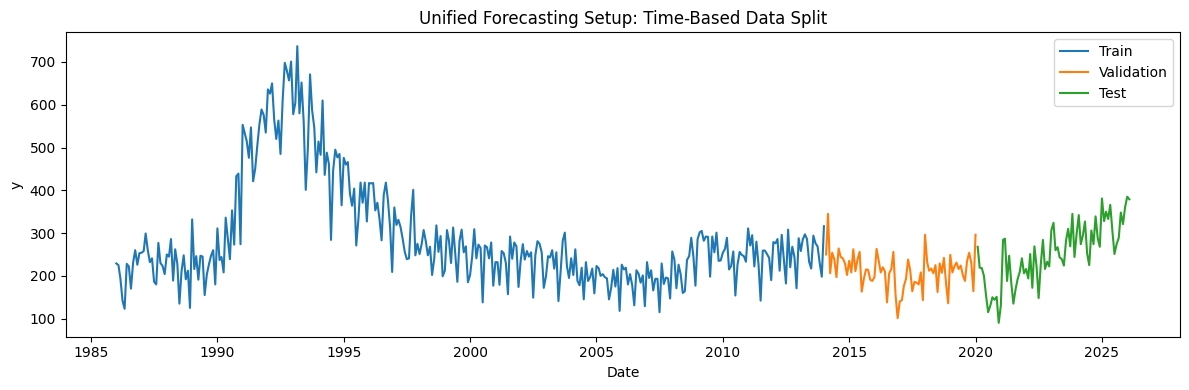

In [56]:
train_frac = 0.7
val_frac = 0.15

n = len(df)
train_end = int(n * train_frac)
val_end = int(n * (train_frac + val_frac))

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

plt.figure(figsize=(12, 4))
plt.plot(train_df.index, train_df["y"], label="Train")
plt.plot(val_df.index, val_df["y"], label="Validation")
plt.plot(test_df.index, test_df["y"], label="Test")
plt.title("Unified Forecasting Setup: Time-Based Data Split")
plt.xlabel("Date")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
def add_features(data: pd.DataFrame) -> pd.DataFrame:

    out = data.copy()

    out["lag1"] = out["y"].shift(1)
    out["lag4"] = out["y"].shift(4)
    out["lag8"] = out["y"].shift(8)


    out["roll_mean_4"] = out["y"].shift(1).rolling(4).mean()
    out["roll_std_4"] = out["y"].shift(1).rolling(4).std()
    return out

feat_df = add_features(df)

n = len(feat_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_feat = feat_df.iloc[:train_end].copy()
val_feat = feat_df.iloc[train_end:val_end].copy()
test_feat = feat_df.iloc[val_end:].copy()

y_mean = train_feat["y"].mean()
y_std = train_feat["y"].std(ddof=0)

for value in [train_feat, val_feat, test_feat]:
    value["y_scaled"] = (value["y"] - y_mean) / (y_std + 1e-8)


feature_cols = ["y_scaled", "lag1", "lag4", "lag8", "roll_mean_4", "roll_std_4"]

to_scale_extra = ["lag1", "lag4", "lag8", "roll_mean_4", "roll_std_4"]
extra_means = train_feat[to_scale_extra].mean()
extra_stds = train_feat[to_scale_extra].std(ddof=0).replace(0, 1.0)

for value in [train_feat, val_feat, test_feat]:
    value[to_scale_extra] = (value[to_scale_extra] - extra_means) / (extra_stds + 1e-8)

train_feat = train_feat.dropna()
val_feat = val_feat.dropna()
test_feat = test_feat.dropna()

WINDOW_SIZE = 12
HORIZON = 1

def make_windows(data: pd.DataFrame, feature_columns, target_col="y_scaled", window_size=WINDOW_SIZE, horizon = HORIZON):
    values = data[feature_columns].values.astype(np.float32)
    target = data[target_col].values.astype(np.float32)
    ds_vals = data.index.values

    x_list, y_list, ds_list = [], [], []
    max_i = len(data) - window_size - horizon - 1

    for i in range(len(data) - window_size - horizon + 1):
        x_win = values[i : i + window_size]
        y_win = target[i + window_size : i + window_size + horizon]
        ds_t = ds_vals[i + window_size + horizon - 1]

        x_list.append(x_win)
        y_list.append(y_win)
        ds_list.append(ds_t)

    X = np.array(x_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    ds_target = np.array(ds_list)

    return X, y, ds_target

x_train, y_train, ds_train_t = make_windows(train_feat, feature_cols, window_size=WINDOW_SIZE, horizon=HORIZON)
x_val, y_val, ds_val_t = make_windows(val_feat, feature_cols, window_size=WINDOW_SIZE, horizon=HORIZON)
x_test, y_test, ds_test_t = make_windows(test_feat, feature_cols, window_size=WINDOW_SIZE, horizon=HORIZON)


In [58]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cpu")

y_train_1 = y_train[:, 0:1].astype(np.float32)
y_val_1 = y_val[:, 0:1].astype(np.float32)
y_test_1 = y_test[:, 0:1].astype(np.float32)

batch_size = 64

train_ds = TensorDataset(torch.tensor(x_train, dtype=torch.float32), torch.tensor(y_train_1, dtype=torch.float32))

val_ds   = TensorDataset(torch.tensor(x_val, dtype=torch.float32), torch.tensor(y_val_1, dtype=torch.float32))

test_ds  = TensorDataset(torch.tensor(x_test, dtype=torch.float32), torch.tensor(y_test_1, dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

input_size = x_train.shape[2]

In [59]:
class LSTMForecaster(nn.Module):
    def __init__ (self, input_size, hidden_size = 32, num_layers=1, dropout=0.0):
        super().__init__()
        self.rnn = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout = dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last = out[:, -1, :]
        yhat = self.fc(last)
        return yhat
    
class GRUForecaster(nn.Module):
    def __init__ (self, input_size, hidden_size = 32, num_layers = 1, dropout=0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last = out[:, -1, :]
        yhat = self.fc(last)
        return yhat
    
def run_epoch(model, loader, criterion, optimizer = None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_train:
            optimizer.zero_grad()

        pred = model(xb)
        loss = criterion(pred, yb)

        if is_train:
            loss.backward()
            optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        n += bs

    return total_loss / max(n,1)


@torch.no_grad()
def predict_model(model, loader):
    model.eval()
    preds = []
    trues = []

    for xb, yb in loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        preds.append(pred)
        trues.append(yb.numpy())
    return np.vstack(preds).ravel(), np.vstack(trues).ravel()

def train_with_early_stopping(model, train_loader, val_loader, lr=1e-3, max_epochs = 40, patience=6):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_state = None
    best_val = np.inf
    wait = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        train_loss = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_loss = run_epoch(model, val_loader, criterion, optimizer=None)
        history.append((epoch, train_loss, val_loss))

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    
    return history, best_val

def forecast(model, last_window, steps = 8):
    model.eval()
    
    window = last_window.copy()
    preds = []

    for _ in range(steps):
        x = torch.tensor(window, dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():
            pred = model(x).cpu().numpy().ravel()[0]

        preds.append(pred)

        new_row = window[-1].copy()

        new_row[0] = pred
            
        window = np.vstack([window[1:], new_row])
        
    return np.array(preds)
    
def inv_scale(y_scaled, mean_, std_):
    return y_scaled * (std_ + 1e-8) + mean_

future_dates = pd.date_range(
    start=test_df.index[-1] + pd.offsets.QuarterBegin(),
    periods=8,
    freq="QS"
)

In [60]:
lstm_model = LSTMForecaster(input_size=input_size, hidden_size=32, num_layers=1).to(device)
lstm_hist, lstm_best_val = train_with_early_stopping(lstm_model, train_loader, val_loader, lr=1e-3, max_epochs=40, patience=6)

lstm_val_pred_s, lstm_val_true_s = predict_model(lstm_model, val_loader)
lstm_test_pred_s, lstm_test_true_s = predict_model(lstm_model, test_loader)

lstm_val_pred = inv_scale(lstm_val_pred_s, y_mean, y_std)
lstm_val_true = inv_scale(lstm_val_true_s, y_mean, y_std)
lstm_test_pred = inv_scale(lstm_test_pred_s, y_mean, y_std)
lstm_test_true = inv_scale(lstm_test_true_s, y_mean, y_std)

gru_model = GRUForecaster(input_size=input_size, hidden_size=32, num_layers=1).to(device)
gru_hist, gru_best_val = train_with_early_stopping(
    gru_model, train_loader, val_loader, lr=1e-3, max_epochs=40, patience=6
)

gru_val_pred_s, gru_val_true_s = predict_model(gru_model, val_loader)
gru_test_pred_s, gru_test_true_s = predict_model(gru_model, test_loader)

gru_val_pred = inv_scale(gru_val_pred_s, y_mean, y_std)
gru_val_true = inv_scale(gru_val_true_s, y_mean, y_std)
gru_test_pred = inv_scale(gru_test_pred_s, y_mean, y_std)
gru_test_true = inv_scale(gru_test_true_s, y_mean, y_std)

rnn_results = {
    "lstm": {
        "val_pred": lstm_val_pred, "val_true": lstm_val_true,
        "test_pred": lstm_test_pred, "test_true": lstm_test_true
    },
    "gru": {
        "val_pred": gru_val_pred, "val_true": gru_val_true,
        "test_pred": gru_test_pred, "test_true": gru_test_true
    }
}

future_scaled = forecast(gru_model, x_test[-1], steps=8)
future = inv_scale(future_scaled, y_mean, y_std)

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

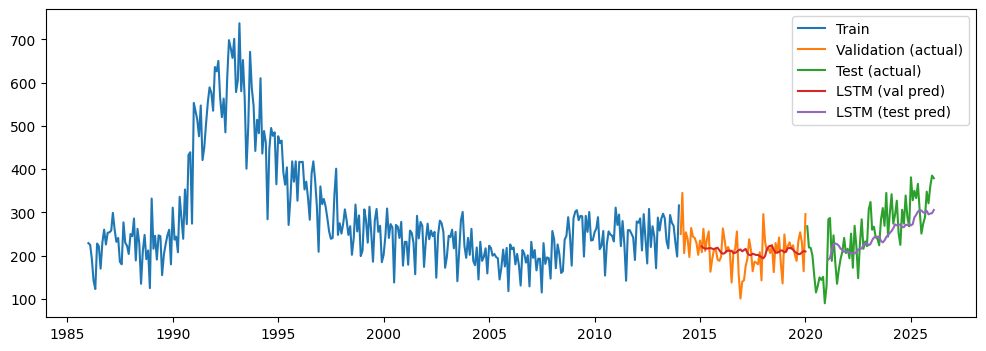

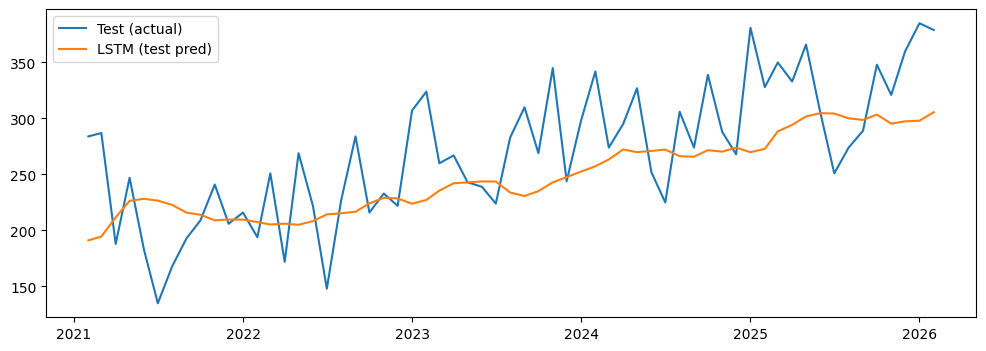

MAE (validation): 29.630
RMSE (validation): 39.752
MAE (test): 40.755
RMSE (test): 50.960


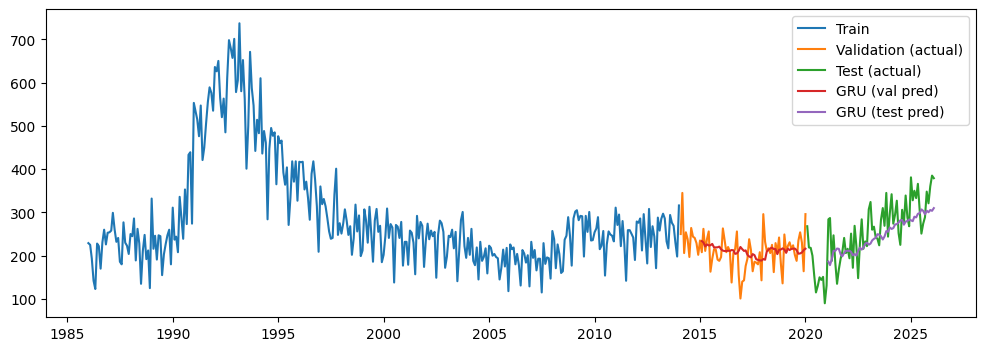

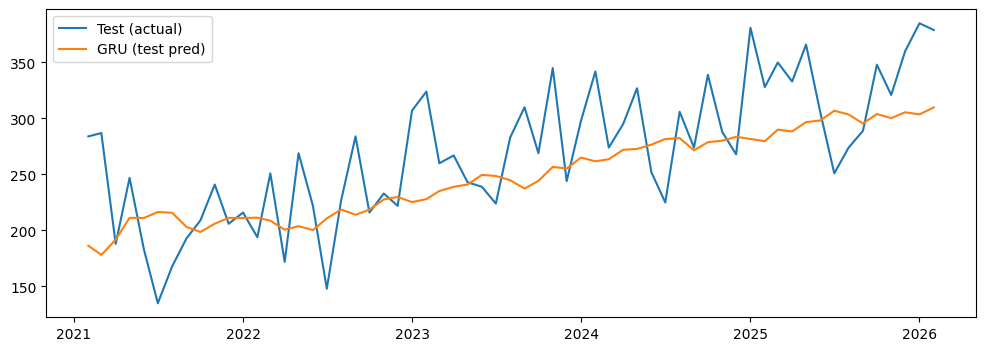

MAE (validation): 30.077
RMSE (validation): 40.038
MAE (test): 39.103
RMSE (test): 49.014


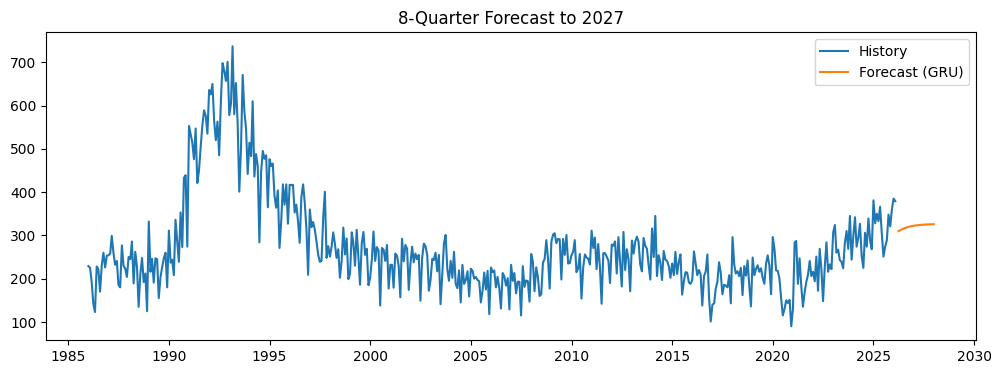

[309.90253458 315.85924057 319.84663599 322.34478422 323.88921555
 324.85000027 325.46381083 325.85675176]


In [ ]:
ds_val_plot = pd.to_datetime(ds_val_t)
ds_test_plot = pd.to_datetime(ds_test_t)

def plot_model_forecast_like_prophet(model_name, val_dates, val_true, val_pred, test_dates, test_true, test_pred):
    plt.figure(figsize=(12, 4))
    plt.plot(train_df.index, train_df["y"], label="Train")
    plt.plot(val_df.index, val_df["y"], label="Validation (actual)")
    plt.plot(test_df.index, test_df["y"], label="Test (actual)")
    plt.plot(val_dates, val_pred, label=f"{model_name} (val pred)")
    plt.plot(test_dates, test_pred, label=f"{model_name} (test pred)")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(test_dates, test_true, label="Test (actual)")
    plt.plot(test_dates, test_pred, label=f"{model_name} (test pred)")
    plt.legend()
    plt.show()

# LSTM plots
plot_model_forecast_like_prophet(
    model_name="LSTM",
    val_dates=ds_val_plot,
    val_true=rnn_results["lstm"]["val_true"],
    val_pred=rnn_results["lstm"]["val_pred"],
    test_dates=ds_test_plot,
    test_true=rnn_results["lstm"]["test_true"],
    test_pred=rnn_results["lstm"]["test_pred"],
)
print(f"MAE (validation): {mae(rnn_results["lstm"]["val_true"], rnn_results["lstm"]["val_pred"]):.3f}")
print(f"RMSE (validation): {rmse(rnn_results["lstm"]["val_true"], rnn_results["lstm"]["val_pred"]):.3f}")
print(f"MAE (test): {mae(rnn_results["lstm"]["test_true"], rnn_results["lstm"]["test_pred"]):.3f}")
print(f"RMSE (test): {rmse(rnn_results["lstm"]["test_true"], rnn_results["lstm"]["test_pred"]):.3f}")



# GRU plots
plot_model_forecast_like_prophet(
    model_name="GRU",
    val_dates=ds_val_plot,
    val_true=rnn_results["gru"]["val_true"],
    val_pred=rnn_results["gru"]["val_pred"],
    test_dates=ds_test_plot,
    test_true=rnn_results["gru"]["test_true"],
    test_pred=rnn_results["gru"]["test_pred"],
)
print(f"MAE (validation): {mae(rnn_results["gru"]["val_true"], rnn_results["gru"]["val_pred"]):.3f}")
print(f"RMSE (validation): {rmse(rnn_results["gru"]["val_true"], rnn_results["gru"]["val_pred"]):.3f}")
print(f"MAE (test): {mae(rnn_results["gru"]["test_true"], rnn_results["gru"]["test_pred"]):.3f}")
print(f"RMSE (test): {rmse(rnn_results["gru"]["test_true"], rnn_results["gru"]["test_pred"]):.3f}")

plt.figure(figsize=(12,4))

plt.plot(df.index, df["y"], label="History")
plt.plot(future_dates, future, label="Forecast (GRU)")

plt.title("8-Quarter Forecast to 2027 (GRU)")
plt.legend()
plt.show()

print(future)

